TensorFlow Version : 2.20.0
Keras Version      : 3.13.2
NumPy Version      : 2.0.2

================ OR GATE ================

Input:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Output:
 [[0.]
 [1.]
 [1.]
 [1.]]


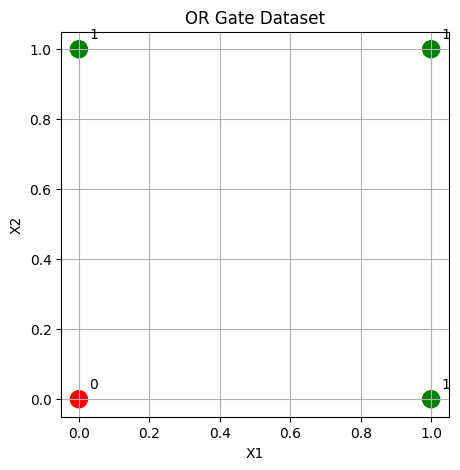


OR Model Summary


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

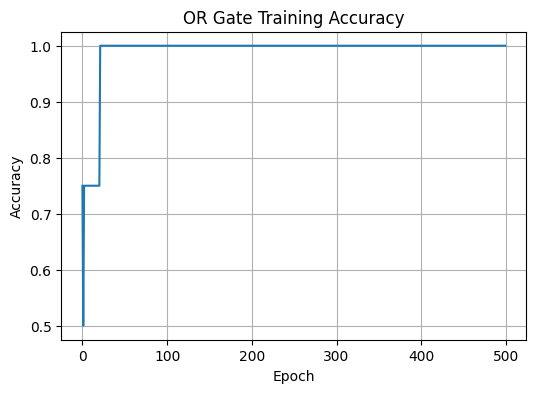

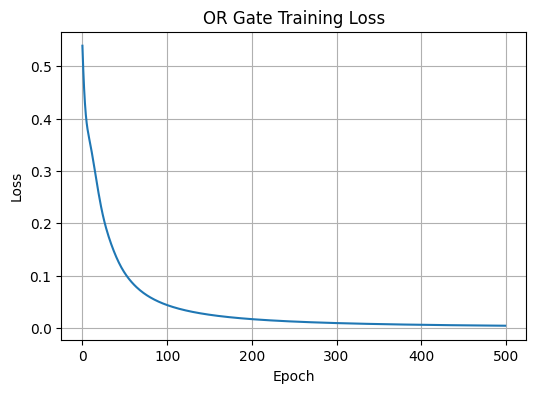

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

Predicted Probabilities:
 [[0.00961686]
 [0.99731445]
 [0.99477386]
 [0.9999999 ]]

Predicted Classes:
 [[0]
 [1]
 [1]
 [1]]

Actual   Predicted
0         0
1         1
1         1
1         1

Weights:
 [[ 9.883419]
 [10.551766]]
Bias:
 [-4.634574]

Accuracy: 1.0

Confusion Matrix:
 [[1 0]
 [0 3]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         1
         1.0       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



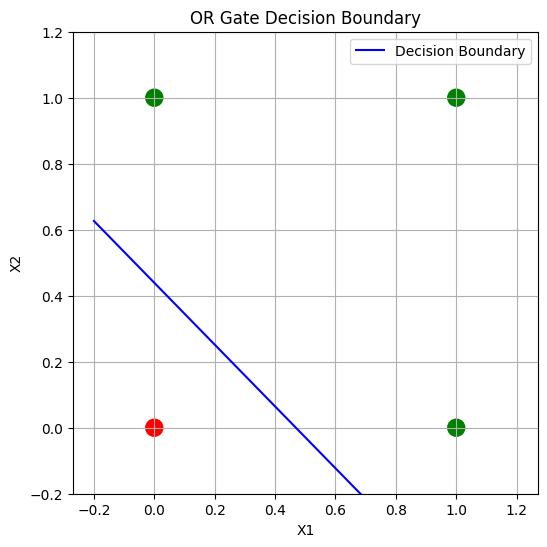


================ NOT GATE ================

Input:
 [[0.]
 [1.]]

Output:
 [[1.]
 [0.]]


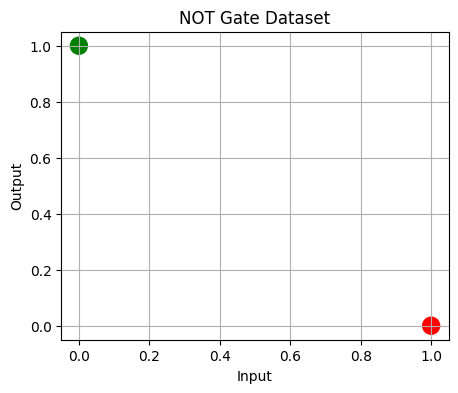


NOT Model Summary


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

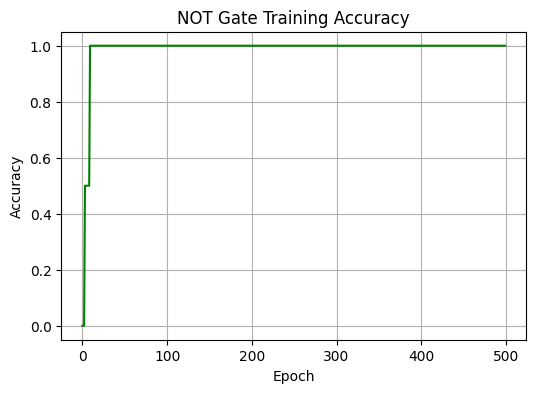

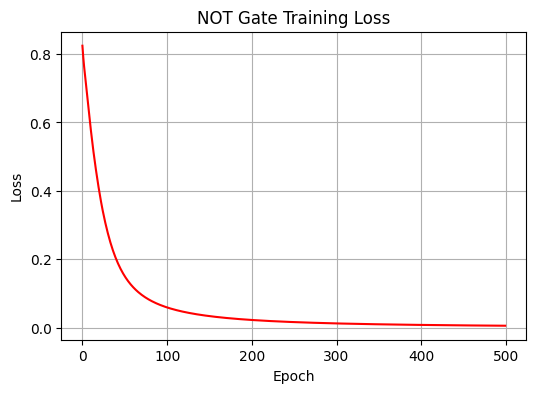

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step

Predicted Probabilities:
 [[0.993952  ]
 [0.00565272]]

Predicted Classes:
 [[1]
 [0]]

Actual   Predicted
1         1
0         0

Weights:
 [[-10.271905]]
Bias:
 [5.1019545]

Accuracy: 1.0

Confusion Matrix:
 [[1 0]
 [0 1]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         1
         1.0       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



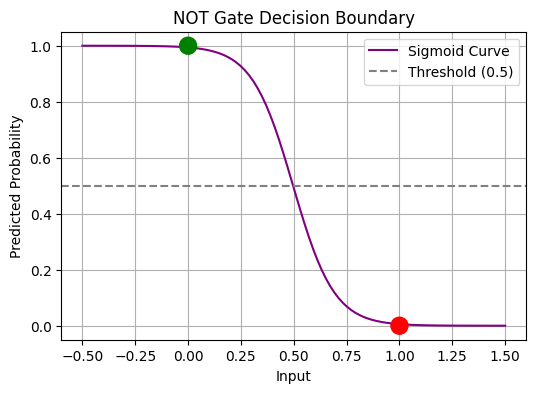

In [ ]:
# ============================================================
# EXPERIMENT-1
# Perceptron Learning Algorithm for OR Gate and NOT Gate
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -----------------------------
# Verify Versions
# -----------------------------
print("TensorFlow Version :", tf.__version__)
print("Keras Version      :", tf.keras.__version__)
print("NumPy Version      :", np.__version__)

# ============================================================
# OR GATE
# ============================================================

print("\n================ OR GATE ================\n")

# 1. Dataset
X_or = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=np.float32)

y_or = np.array([
    [0],
    [1],
    [1],
    [1]
], dtype=np.float32)

print("Input:\n", X_or)
print("\nOutput:\n", y_or)

# 2. Plot Dataset
plt.figure(figsize=(5, 5))
colors_or = ['red' if i == 0 else 'green' for i in y_or.flatten()]
plt.scatter(X_or[:, 0], X_or[:, 1], c=colors_or, s=150)
for i in range(len(X_or)):
    plt.text(X_or[i, 0] + 0.03, X_or[i, 1] + 0.03, str(int(y_or[i][0])))
plt.title("OR Gate Dataset")
plt.xlabel("X1")
plt.ylabel("X2")
plt.grid(True)
plt.show()

# 3. Modern Keras 3 Sequential Model
model_or = Sequential([
    Input(shape=(2,)),
    Dense(1, activation='sigmoid')
])

print("\nOR Model Summary")
model_or.summary()

# 4. Compile Model (Higher learning rate to ensure 100% convergence)
model_or.compile(
    optimizer=Adam(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 5. Train Model
history_or = model_or.fit(
    X_or,
    y_or,
    epochs=500,
    verbose=0
)

# 6. Learning Curves (Accuracy & Loss)
plt.figure(figsize=(6, 4))
plt.plot(history_or.history['accuracy'])
plt.title("OR Gate Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history_or.history['loss'])
plt.title("OR Gate Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# 7. Predictions
prob_or = model_or.predict(X_or)
pred_or = (prob_or > 0.5).astype(int)

print("\nPredicted Probabilities:\n", prob_or)
print("\nPredicted Classes:\n", pred_or)

print("\nActual   Predicted")
for a, p in zip(y_or, pred_or):
    print(int(a[0]), "       ", int(p[0]))

# 8. Weights and Bias
weights_or, bias_or = model_or.layers[0].get_weights()
print("\nWeights:\n", weights_or)
print("Bias:\n", bias_or)

# 9. Performance Metrics
print("\nAccuracy:", accuracy_score(y_or, pred_or))
print("\nConfusion Matrix:\n", confusion_matrix(y_or, pred_or))
print("\nClassification Report:\n", classification_report(y_or, pred_or, zero_division=0))

# 10. Decision Boundary
w1, w2 = weights_or[0][0], weights_or[1][0]
b_or = bias_or[0]
x_or = np.linspace(-0.2, 1.2, 100)
y_boundary = -(w1 * x_or + b_or) / w2

plt.figure(figsize=(6, 6))
plt.scatter(X_or[:, 0], X_or[:, 1], c=colors_or, s=150)
plt.plot(x_or, y_boundary, label="Decision Boundary", color="blue")
plt.title("OR Gate Decision Boundary")
plt.xlabel("X1")
plt.ylabel("X2")
plt.ylim(-0.2, 1.2)
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# NOT GATE
# ============================================================

print("\n================ NOT GATE ================\n")

# 1. Dataset
X_not = np.array([
    [0],
    [1]
], dtype=np.float32)

y_not = np.array([
    [1],
    [0]
], dtype=np.float32)

print("Input:\n", X_not)
print("\nOutput:\n", y_not)

# 2. Plot Dataset
plt.figure(figsize=(5, 4))
colors_not = ['green' if i == 1 else 'red' for i in y_not.flatten()]
plt.scatter(X_not, y_not, c=colors_not, s=150)
plt.title("NOT Gate Dataset")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.show()

# 3. Modern Keras 3 Sequential Model
model_not = Sequential([
    Input(shape=(1,)),
    Dense(1, activation='sigmoid')
])

print("\nNOT Model Summary")
model_not.summary()

# 4. Compile Model
model_not.compile(
    optimizer=Adam(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 5. Train Model
history_not = model_not.fit(
    X_not,
    y_not,
    epochs=500,
    verbose=0
)

# 6. Learning Curves (Accuracy & Loss)
plt.figure(figsize=(6, 4))
plt.plot(history_not.history['accuracy'], color='green')
plt.title("NOT Gate Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history_not.history['loss'], color='red')
plt.title("NOT Gate Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# 7. Predictions
prob_not = model_not.predict(X_not)
pred_not = (prob_not > 0.5).astype(int)

print("\nPredicted Probabilities:\n", prob_not)
print("\nPredicted Classes:\n", pred_not)

print("\nActual   Predicted")
for a, p in zip(y_not, pred_not):
    print(int(a[0]), "       ", int(p[0]))

# 8. Weights and Bias
weights_not, bias_not = model_not.layers[0].get_weights()
print("\nWeights:\n", weights_not)
print("Bias:\n", bias_not)

# 9. Performance Metrics
print("\nAccuracy:", accuracy_score(y_not, pred_not))
print("\nConfusion Matrix:\n", confusion_matrix(y_not, pred_not))
print("\nClassification Report:\n", classification_report(y_not, pred_not, zero_division=0))

# 10. Decision Boundary (Sigmoid curve over inputs)
x_not = np.linspace(-0.5, 1.5, 100)
z = weights_not[0][0] * x_not + bias_not[0]
pred_curve = 1 / (1 + np.exp(-z))

plt.figure(figsize=(6, 4))
plt.scatter(X_not, y_not, c=colors_not, s=150, zorder=5)
plt.plot(x_not, pred_curve, label="Sigmoid Curve", color="purple")
plt.axhline(0.5, color='gray', linestyle='--', label="Threshold (0.5)")
plt.title("NOT Gate Decision Boundary")
plt.xlabel("Input")
plt.ylabel("Predicted Probability")
plt.grid(True)
plt.legend()
plt.show()